In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Loading Data
df = pd.read_csv('customs_clearance_data.csv')


# Step 1: Drop missing release_date rows
df = df.dropna(subset=['release_date'])
print(f"Step 1 - Rows after dropping missing: {len(df)}")

# Step 2: Convert dates
df['entry_date'] = pd.to_datetime(df['entry_date'])
df['accepted_date'] = pd.to_datetime(df['accepted_date'])
df['release_date'] = pd.to_datetime(df['release_date'])

print("Step 2 - Dates converted!")

# Step 3: Verify with df.info()
print("\n=== VERIFY WITH df.info() ===")
df.info()

# Step 4: Show sample
print("\n=== SAMPLE DATES ===")
print(df[['entry_date', 'accepted_date', 'release_date']].head(3))

# Step 5: Calculate clearance hours
df['clearance_hours'] = (df['release_date'] - df['entry_date']).dt.total_seconds() / 3600

print("\n=== CLEARANCE HOURS ===")
print(df['clearance_hours'].describe())

Step 1 - Rows after dropping missing: 5145
Step 2 - Dates converted!

=== VERIFY WITH df.info() ===
<class 'pandas.DataFrame'>
Index: 5145 entries, 0 to 5249
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   shipment_id            5145 non-null   str           
 1   entry_no               5145 non-null   str           
 2   hs_code                4892 non-null   str           
 3   product_desc           5145 non-null   str           
 4   supplier               5145 non-null   str           
 5   country_origin         4989 non-null   str           
 6   country_destination    5145 non-null   str           
 7   declared_value_usd     5145 non-null   float64       
 8   invoice_value_usd      5145 non-null   float64       
 9   weight_kg              5145 non-null   float64       
 10  volume_m3              5145 non-null   float64       
 11  broker                 5145 non-null 

In [2]:
# COMPLETE DATA CLEANING PIPELINE 

print("=" * 50)
print("STARTING DATA CLEANING PIPELINE")
print("=" * 50)

# 1. HANDLE MISSING VALUES

print("\n[1] HANDLING MISSING VALUES")

# Drop rows where release_date is missing
df = df.dropna(subset=['release_date'])
print(f"  → Dropped rows with missing release_date: {len(df)} rows remaining")

# Fill missing country_origin with 'UNKNOWN'
df['country_origin'] = df['country_origin'].fillna('UNKNOWN')
print(f"  → Filled missing country_origin: {df['country_origin'].isin(['UNKNOWN']).sum()} rows")

# 2. REMOVE DUPLICATE ENTRIES

print("\n[2] REMOVING DUPLICATE ENTRIES")

duplicate_count = df.duplicated(subset=['entry_no']).sum()
df = df.drop_duplicates(subset=['entry_no'], keep='first')
print(f"  → Removed {duplicate_count} duplicate entries")


# 3. STANDARDIZE TEXT FIELDS

print("\n[3] STANDARDIZING TEXT FIELDS")

text_cols = ['broker', 'port_of_entry', 'country_origin', 'supplier', 'product_desc', 'incoterm']
for col in text_cols:
    df[col] = df[col].astype(str).str.upper().str.strip()
    df[col] = df[col].replace(['', 'NAN', 'NONE'], 'UNKNOWN')
print(f"  → Standardized {len(text_cols)} text columns")

# 4. DATE VALIDATION

print("\n[4] VALIDATING DATES")

df['entry_date'] = pd.to_datetime(df['entry_date'])
df['accepted_date'] = pd.to_datetime(df['accepted_date'])
df['release_date'] = pd.to_datetime(df['release_date'])

invalid_dates = df[df['release_date'] < df['entry_date']]
df.loc[df['release_date'] < df['entry_date'], 'release_date'] = df.loc[df['release_date'] < df['entry_date'], 'entry_date'] + pd.Timedelta(hours=24)
print(f"  → Fixed {len(invalid_dates)} invalid dates")

# 5. OUTLIER TREATMENT

print("\n[5] TREATING OUTLIERS")

weight_95 = df['weight_kg'].quantile(0.95)
weight_capped = (df['weight_kg'] > weight_95).sum()
df['weight_kg'] = df['weight_kg'].clip(upper=weight_95)
print(f"  → Capped {weight_capped} weight outliers at {weight_95:.2f} kg")

value_99 = df['declared_value_usd'].quantile(0.99)
value_capped = (df['declared_value_usd'] > value_99).sum()
df['declared_value_usd'] = df['declared_value_usd'].clip(upper=value_99)
print(f"  → Capped {value_capped} value outliers at ${value_99:,.2f}")

# 6. HS CODE CLEANING (YOUR CODE)

print("\n[6] CLEANING HS CODES")

# Step 1: Remove 'X' from HS codes and clean
df['hs_code_clean'] = df['hs_code'].astype(str).str.replace('X', '').str.strip()
df['hs_code_clean'] = df['hs_code_clean'].replace(['nan', 'None', ''], 'UNKNOWN')

# Step 2: Extract HS category (first 2 digits)
df['hs_category'] = df['hs_code_clean'].str[:2]

# Step 3: Flag invalid HS codes (not 6 digits or not numeric)
df['hs_code_invalid'] = (
    ~df['hs_code_clean'].str.isdigit() | 
    (df['hs_code_clean'].str.len() != 6)
).astype(int)

# Step 4: Replace original hs_code with cleaned version
df['hs_code'] = df['hs_code_clean']
df = df.drop(columns=['hs_code_clean'])

print(f"  → Invalid HS codes: {df['hs_code_invalid'].sum()}")
print(f"  → Unknown HS codes: {(df['hs_code'] == 'UNKNOWN').sum()}")

# 7. LICENSE COMPLIANCE FLAG

print("\n[7] FLAGGING LICENSE COMPLIANCE")

df['license_missing'] = ((df['license_required'] == 'Y') & (df['license_obtained'] == 'N')).astype(int)
print(f"  → Missing licenses flagged: {df['license_missing'].sum()}")

STARTING DATA CLEANING PIPELINE

[1] HANDLING MISSING VALUES
  → Dropped rows with missing release_date: 5145 rows remaining
  → Filled missing country_origin: 156 rows

[2] REMOVING DUPLICATE ENTRIES
  → Removed 361 duplicate entries

[3] STANDARDIZING TEXT FIELDS
  → Standardized 6 text columns

[4] VALIDATING DATES
  → Fixed 0 invalid dates

[5] TREATING OUTLIERS
  → Capped 240 weight outliers at 4825.15 kg
  → Capped 48 value outliers at $148,504.06

[6] CLEANING HS CODES
  → Invalid HS codes: 240
  → Unknown HS codes: 4

[7] FLAGGING LICENSE COMPLIANCE
  → Missing licenses flagged: 64


Feature Engineering

In [3]:
print("\n[8] CREATING NEW FEATURES")

# Clearance time in hours
df['clearance_hours'] = (df['release_date'] - df['entry_date']).dt.total_seconds() / 3600

# Slow clearance flag (> 48 hours)
df['slow_clearance'] = (df['clearance_hours'] > 48).astype(int)

# Valuation discrepancy
df['valuation_discrepancy_pct'] = ((df['invoice_value_usd'] / df['declared_value_usd']) - 1) * 100
df['high_discrepancy'] = (df['valuation_discrepancy_pct'] > 20).astype(int)

# High-risk origin flag
high_risk_origins = ['CHINA', 'INDIA', 'TURKEY', 'VIETNAM', 'THAILAND']
df['high_risk_origin'] = df['country_origin'].isin(high_risk_origins).astype(int)

# Demurrage cost
df['excess_days'] = np.maximum(0, (df['clearance_hours'] - 48) / 24)
df['demurrage_cost'] = df['excess_days'] * 50

print(f"  → Created 7 new features")

# 9. FINAL SUMMARY

print("\n" + "=" * 50)
print("DATA CLEANING COMPLETE")
print("=" * 50)
print(f"Final dataset shape: {df.shape}")
print(f"Total columns: {len(df.columns)}")

print("\n=== SAMPLE CLEANED DATA ===")
df.head(3)


[8] CREATING NEW FEATURES
  → Created 7 new features

DATA CLEANING COMPLETE
Final dataset shape: (4784, 35)
Total columns: 35

=== SAMPLE CLEANED DATA ===


,shipment_id,entry_no,hs_code,product_desc,supplier,country_origin,country_destination,declared_value_usd,invoice_value_usd,weight_kg,...,slow_clearance,clearance_hours,hs_category,hs_code_invalid,license_missing,valuation_discrepancy_pct,high_discrepancy,high_risk_origin,excess_days,demurrage_cost
0,SHIP000001,22EMKIM499458,303286,MEDICINAL PREPARATIONS,AGRITECH SOLUTIONS,TANZANIA,UGANDA,25061.0,25074.42,2950.44,...,0,4.0,30,0,0,0.053549,0,0,0.0,0.0
1,SHIP000002,22EMKIM437930,306514,MEDICINAL PREPARATIONS,INDUSTRIAL SUPPLY CO,GHANA,SOUTH AFRICA,141068.0,208861.59,357.08,...,0,4.0,30,0,0,48.057384,1,0,0.0,0.0
2,SHIP000003,22EMKIM404207,398428,PLASTIC COMPONENTS,MEDICARE SOLUTIONS,MOZAMBIQUE,KENYA,45362.0,44204.41,4215.83,...,0,0.0,39,0,0,-2.551894,0,0,0.0,0.0


In [4]:
df['hs_code'].unique()
# HS code cleaned

<StringArray>
['303286', '306514', '398428', '624483', '702040', '399317', '873103',
 '302104',      nan, '738956',
 ...
 '404834', '856204', '844975', '707266', '873087', '301997', '703530',
 '736815', '842616', '708650']
Length: 4427, dtype: str

Analysis

Broker Performance Analysis

In [6]:
df["broker"].unique()

<StringArray>
[   'DHL GLOBAL FORWARDING',             'KUEHNE NAGEL',
                'PANALPINA',        'BOLLORE LOGISTICS',
 'EXPEDITORS INTERNATIONAL',        'AGILITY LOGISTICS']
Length: 6, dtype: str

In [11]:
# Analyzing the stats for the six brokers

broker_stats = df.groupby('broker').agg(
    total_shipments=('entry_no', 'count'),
    avg_clearance_hrs=('clearance_hours', 'mean'),
    slow_clearance_pct=('slow_clearance', 'mean'),
    avg_broker_fee=('broker_fee_usd', 'mean'),
    total_demurrage=('demurrage_cost', 'sum')
).round(2).sort_values('slow_clearance_pct', ascending=False)

broker_stats

,total_shipments,avg_clearance_hrs,slow_clearance_pct,avg_broker_fee,total_demurrage
broker,,,,,
EXPEDITORS INTERNATIONAL,237,33.40,0.15,259.03,2858.33
DHL GLOBAL FORWARDING,2462,33.37,0.15,224.42,28481.25
PANALPINA,198,31.88,0.15,319.28,1900.00
BOLLORE LOGISTICS,683,31.96,0.14,324.93,7277.08
KUEHNE NAGEL,984,32.55,0.14,224.02,10691.67
AGILITY LOGISTICS,220,34.00,0.12,252.82,2622.92


In [12]:
# Demurrage Cost by Broker
cost_by_broker = df.groupby('broker').agg(
    total_demurrage=('demurrage_cost', 'sum'),
    avg_demurrage=('demurrage_cost', 'mean'),
    total_shipments=('entry_no', 'count')
).round(2).sort_values('total_demurrage', ascending=False)

print("\n=== DEMURRAGE COST BY BROKER ===")
print(cost_by_broker)

# 3. Prepare for multi-metric comparison
broker_compare = broker_stats[['slow_clearance_pct', 'avg_clearance_hrs', 'avg_broker_fee']].copy()
broker_compare['broker'] = broker_compare.index

# Normalize each metric (0-1 scale, where 0 = best)
for col in ['slow_clearance_pct', 'avg_clearance_hrs', 'avg_broker_fee']:
    broker_compare[f'{col}_norm'] = (broker_compare[col] - broker_compare[col].min()) / (broker_compare[col].max() - broker_compare[col].min())

print("\n=== BROKER COMPARISON (NORMALIZED) ===")
print(broker_compare[['broker', 'slow_clearance_pct_norm', 'avg_clearance_hrs_norm', 'avg_broker_fee_norm']])


=== DEMURRAGE COST BY BROKER ===
                          total_demurrage  avg_demurrage  total_shipments
broker                                                                   
DHL GLOBAL FORWARDING            28481.25          11.57             2462
KUEHNE NAGEL                     10691.67          10.87              984
BOLLORE LOGISTICS                 7277.08          10.65              683
EXPEDITORS INTERNATIONAL          2858.33          12.06              237
AGILITY LOGISTICS                 2622.92          11.92              220
PANALPINA                         1900.00           9.60              198

=== BROKER COMPARISON (NORMALIZED) ===
                                            broker  slow_clearance_pct_norm  \
broker                                                                        
EXPEDITORS INTERNATIONAL  EXPEDITORS INTERNATIONAL                 1.000000   
DHL GLOBAL FORWARDING        DHL GLOBAL FORWARDING                 1.000000   
PANALPINA         

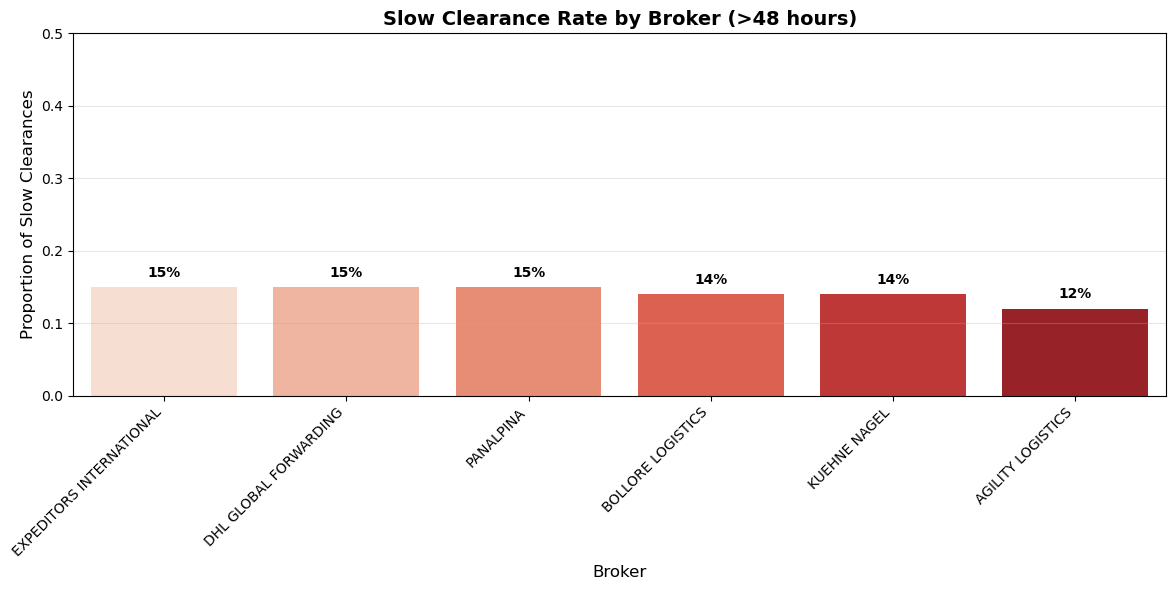

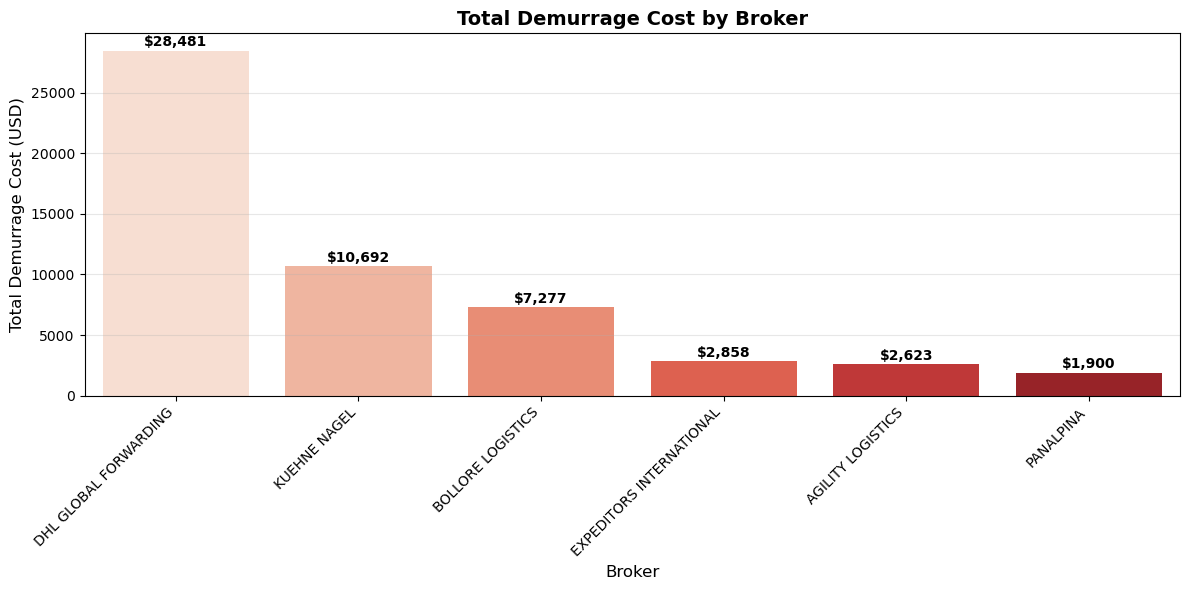

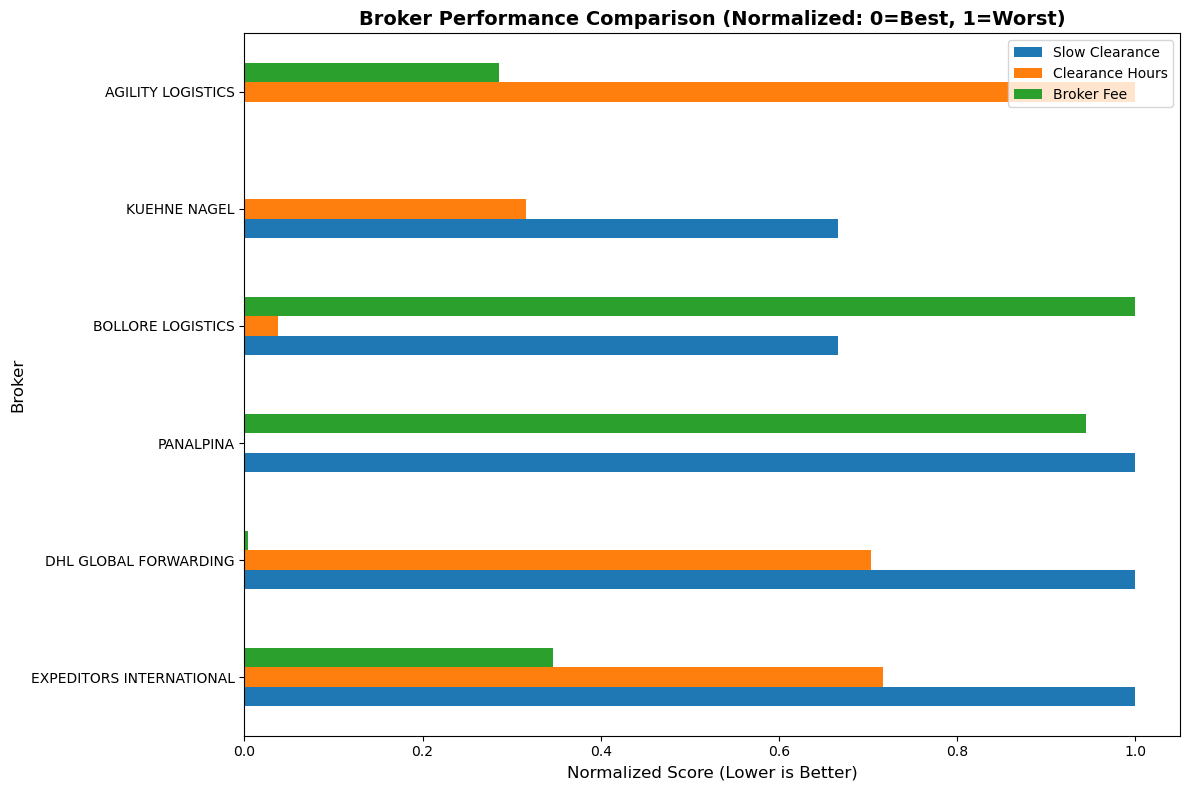

✅ All broker images saved to 'images/' folder!


In [13]:
# BROKER PERFORMANCE VISUALIZATIONS

# 1. Slow Clearance Rate
plt.figure(figsize=(12, 6))
sns.barplot(data=broker_stats.reset_index(), x='broker', y='slow_clearance_pct', palette='Reds')
plt.title('Slow Clearance Rate by Broker (>48 hours)', fontsize=14, fontweight='bold')
plt.xlabel('Broker', fontsize=12)
plt.ylabel('Proportion of Slow Clearances', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 0.5)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(broker_stats['slow_clearance_pct']):
    plt.text(i, v + 0.01, f'{v*100:.0f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('images/broker_slow_rate.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Demurrage Impact
plt.figure(figsize=(12, 6))
sns.barplot(data=cost_by_broker.reset_index(), x='broker', y='total_demurrage', palette='Reds')
plt.title('Total Demurrage Cost by Broker', fontsize=14, fontweight='bold')
plt.xlabel('Broker', fontsize=12)
plt.ylabel('Total Demurrage Cost (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(cost_by_broker['total_demurrage']):
    plt.text(i, v + 100, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('images/broker_demurrage.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Multi-Metric Comparison
fig, ax = plt.subplots(figsize=(12, 8))
broker_compare.set_index('broker')[['slow_clearance_pct_norm', 'avg_clearance_hrs_norm', 'avg_broker_fee_norm']].plot(kind='barh', ax=ax)
ax.set_title('Broker Performance Comparison (Normalized: 0=Best, 1=Worst)', fontsize=14, fontweight='bold')
ax.set_xlabel('Normalized Score (Lower is Better)', fontsize=12)
ax.set_ylabel('Broker', fontsize=12)
ax.legend(['Slow Clearance', 'Clearance Hours', 'Broker Fee'])
plt.tight_layout()
plt.savefig('images/broker_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ All broker images saved to 'images/' folder!")

Ports Analysis.

Which ports of entry present the highest risk of delays?

In [14]:
port_stats = df.groupby('port_of_entry').agg(
    total_shipments=('entry_no', 'count'),
    avg_clearance_hrs=('clearance_hours', 'mean'),
    slow_clearance_pct=('slow_clearance', 'mean')
).round(2).sort_values('avg_clearance_hrs', ascending=False)

port_stats

,total_shipments,avg_clearance_hrs,slow_clearance_pct
port_of_entry,,,
PORT ELIZABETH,258,34.91,0.17
LAGOS,723,34.87,0.17
DURBAN,269,34.17,0.15
MOMBASA,719,33.83,0.17
NAIROBI,239,33.15,0.16
DAR ES SALAAM,245,32.38,0.13
ABIDJAN,226,32.31,0.13
TEMA,233,32.00,0.14
CASABLANCA,695,31.99,0.13


=== PORT PERFORMANCE STATISTICS ===
                total_shipments  avg_clearance_hrs  median_clearance_hrs  \
port_of_entry                                                              
PORT ELIZABETH              258              34.91                  31.0   
LAGOS                       723              34.87                  29.0   
DURBAN                      269              34.17                  31.0   
MOMBASA                     719              33.83                  28.0   
NAIROBI                     239              33.15                  29.0   
DAR ES SALAAM               245              32.38                  27.0   
ABIDJAN                     226              32.31                  28.0   
TEMA                        233              32.00                  28.0   
CASABLANCA                  695              31.99                  28.0   
CAPE TOWN                   215              31.76                  28.0   
ALEXANDRIA                  723              31.53  

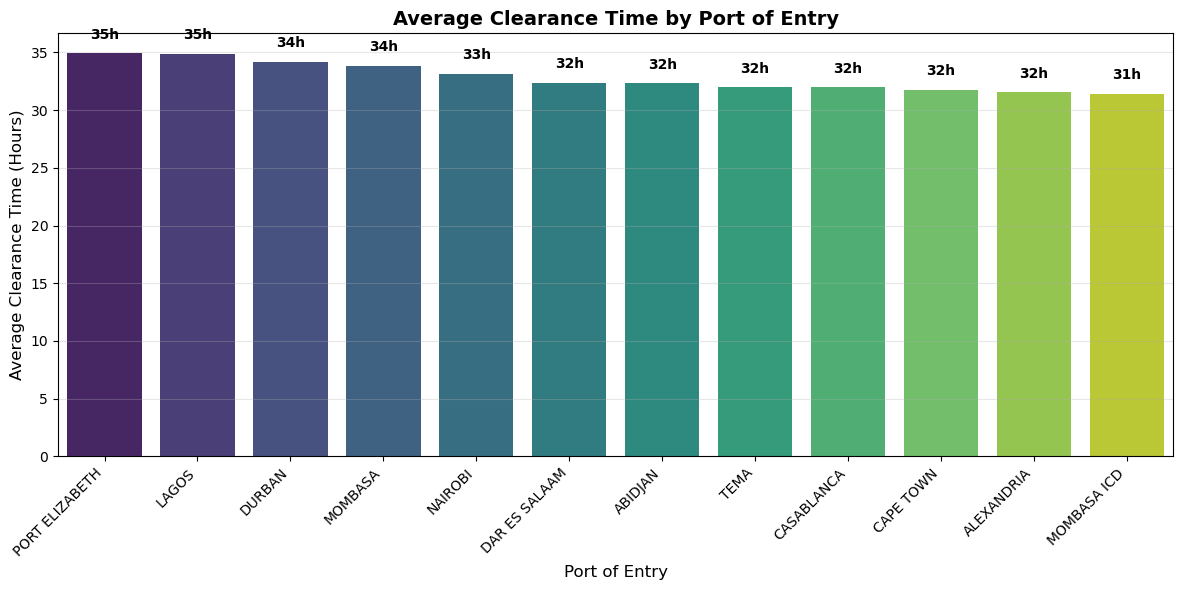

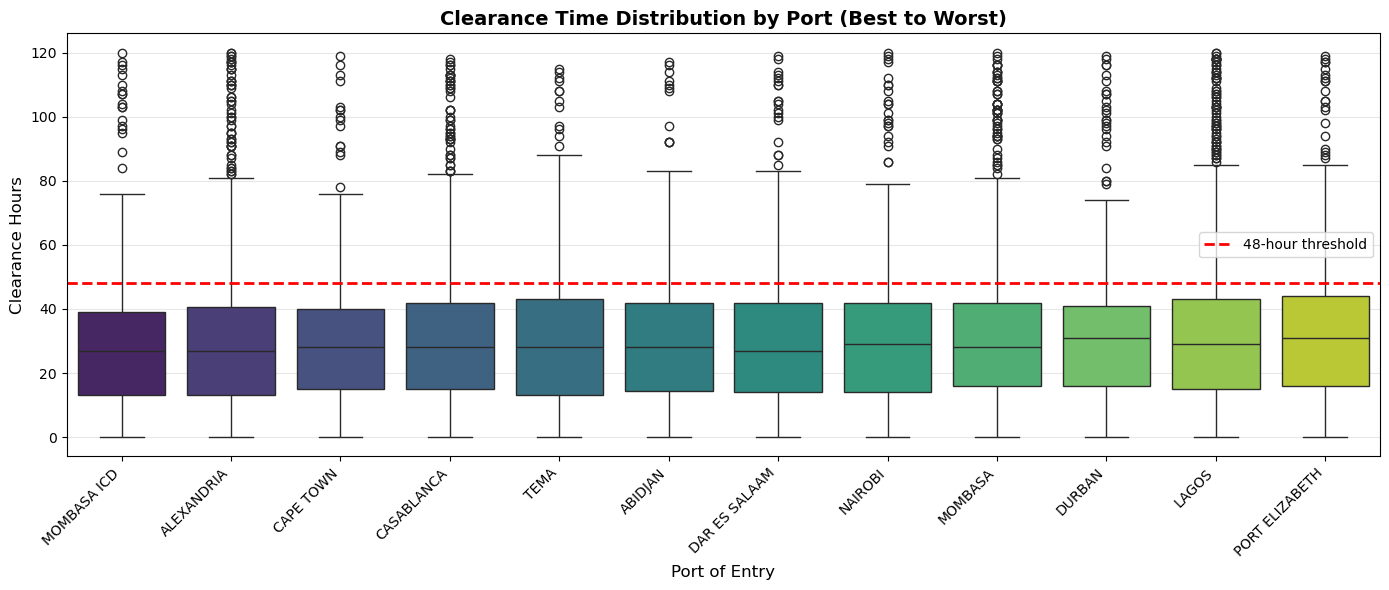

Port order (best to worst): ['MOMBASA ICD', 'ALEXANDRIA', 'CAPE TOWN', 'CASABLANCA', 'TEMA', 'ABIDJAN', 'DAR ES SALAAM', 'NAIROBI', 'MOMBASA', 'DURBAN', 'LAGOS', 'PORT ELIZABETH']

✅ Port analysis images saved to 'images/' folder!


In [16]:
# PORT PERFORMANCE PLOTS

import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create images folder if it doesn't exist
if not os.path.exists('images'):
    os.makedirs('images')

# Port Statistics
port_stats = df.groupby('port_of_entry').agg(
    total_shipments=('entry_no', 'count'),
    avg_clearance_hrs=('clearance_hours', 'mean'),
    median_clearance_hrs=('clearance_hours', 'median'),
    slow_clearance_pct=('slow_clearance', 'mean')
).round(2).sort_values('avg_clearance_hrs', ascending=False)

print("=== PORT PERFORMANCE STATISTICS ===")
print(port_stats)

# PLOT 1: BAR CHART – Average Clearance Time

plt.figure(figsize=(12, 6))
sns.barplot(data=port_stats.reset_index(), 
            x='port_of_entry', 
            y='avg_clearance_hrs', 
            palette='viridis')
plt.title('Average Clearance Time by Port of Entry', fontsize=14, fontweight='bold')
plt.xlabel('Port of Entry', fontsize=12)
plt.ylabel('Average Clearance Time (Hours)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(port_stats['avg_clearance_hrs']):
    plt.text(i, v + 1, f'{v:.0f}h', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('images/port_clearance_time.png', dpi=300, bbox_inches='tight')
plt.show()

# PLOT 2: BOXPLOT – Clearance Time Distribution by Port

# Get port order from best (lowest avg clearance) to worst (highest avg clearance)
port_order = port_stats.sort_values('avg_clearance_hrs', ascending=True).index.tolist()

plt.figure(figsize=(14, 6))
sns.boxplot(data=df, 
            x='port_of_entry', 
            y='clearance_hours', 
            order=port_order,  # <-- This orders from best to worst
            palette='viridis')
plt.title('Clearance Time Distribution by Port (Best to Worst)', fontsize=14, fontweight='bold')
plt.xlabel('Port of Entry', fontsize=12)
plt.ylabel('Clearance Hours', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Add horizontal line at 48-hour threshold
plt.axhline(y=48, color='red', linestyle='--', linewidth=2, label='48-hour threshold')
plt.legend()

plt.tight_layout()
plt.savefig('images/port_boxplot_ordered.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Port order (best to worst): {port_order}")

print("\n✅ Port analysis images saved to 'images/' folder!")